# Categorical Data Analysis

In this notebook, we analyze the categorical variables in the Titanic dataset.

The analysis includes unique categories, category frequencies, category distribution, rare categories, cardinality, category imbalance, and the relationship between important categorical variables and the target variable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Identify Categorical Variables

### Concept

Categorical variables contain labels or groups instead of continuous numerical values.

### Example

In the Titanic dataset, Sex and Embarked are categorical variables.

### Implementation

We identify the categorical columns using their data types.

### Output

The output displays the categorical variables available in the dataset.

### Interpretation

These variables can be analyzed using frequencies, percentages, and visualizations.

### Insight

Identifying categorical variables is the first step before performing categorical data analysis.

### AI/ML Relevance

Categorical variables usually need to be encoded into numerical form before they can be used in Machine Learning models.

In [3]:
categorical_cols = df.select_dtypes(include="str").columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## Unique Categories

### Concept

Unique categories represent the different distinct values present in a categorical variable.

### Example

The Sex column contains categories such as male and female.

### Implementation

We display the unique values in important categorical variables.

### Output

The output shows all available categories.

### Interpretation

This helps us understand the possible groups within each variable.

### Insight

Unexpected categories may indicate inconsistent or incorrect data.

### AI/ML Relevance

The number of unique categories helps determine the appropriate encoding method.

In [4]:
for col in ["Sex", "Embarked"]:
    print(f"\n{col} Unique Categories:")
    print(df[col].unique())


Sex Unique Categories:
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Embarked Unique Categories:
<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


## Category Frequencies

### Concept

Category frequency shows how many records belong to each category.

### Example

We can count how many passengers are male and female.

### Implementation

We use value_counts() to calculate the frequency of each category.

### Output

The output displays the number of records in each category.

### Interpretation

Higher counts indicate more common categories, while lower counts indicate less common categories.

### Insight

Frequency analysis helps us understand the composition of the dataset.

### AI/ML Relevance

Very small categories may have limited representation and can affect model training.

In [5]:
print("Sex Frequency:")
print(df["Sex"].value_counts())

print("\nEmbarked Frequency:")
print(df["Embarked"].value_counts())

Sex Frequency:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked Frequency:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


## Category Distribution

### Concept

Category distribution shows the proportion of observations belonging to each category.

### Example

Instead of only counting male and female passengers, we can calculate their percentage distribution.

### Implementation

We calculate percentages and visualize the distribution using a count plot.

### Interpretation

The visualization makes it easier to identify dominant and less common categories.

### Insight

The dataset may contain categories with unequal representation.

### AI/ML Relevance

Understanding category distribution helps identify possible imbalance before model development.

Sex
male      64.76
female    35.24
Name: proportion, dtype: float64


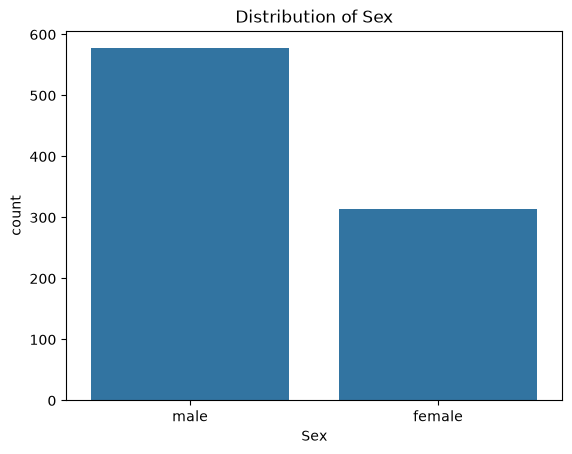

In [6]:
sex_percentage = df["Sex"].value_counts(normalize=True) * 100

print(sex_percentage.round(2))

sns.countplot(data=df, x="Sex")
plt.title("Distribution of Sex")
plt.show()

## Low Cardinality

### Concept

A categorical variable has low cardinality when it contains only a small number of unique categories.

### Example

The Sex column has low cardinality because it contains only a few categories.

### Implementation

We count the number of unique values in important categorical variables.

### Interpretation

Variables with fewer categories are usually easier to analyze and encode.

### AI/ML Relevance

Low-cardinality variables can often be handled using methods such as One-Hot Encoding.

In [7]:
for col in ["Sex", "Embarked"]:
    print(f"{col}: {df[col].nunique()} unique categories")

Sex: 2 unique categories
Embarked: 3 unique categories


## High Cardinality

### Concept

A variable has high cardinality when it contains a large number of unique values.

### Example

The Name column has high cardinality because most passengers have different names.

### Implementation

We compare the number of unique values in Name and other categorical variables.

### Interpretation

A variable with many unique values may not be useful for direct category-based analysis.

### Insight

High-cardinality variables may require feature engineering or may need to be excluded from some models.

### AI/ML Relevance

Direct One-Hot Encoding of high-cardinality variables can create too many features.

In [8]:
print("Name unique values:", df["Name"].nunique())
print("Ticket unique values:", df["Ticket"].nunique())

Name unique values: 891
Ticket unique values: 681


## Rare Categories

### Concept

Rare categories are categories that appear only a small number of times in the dataset.

### Example

A particular Embarked category may have significantly fewer passengers than the other categories.

### Implementation

We identify categories with a frequency below a selected threshold.

### Interpretation

Rare categories should be examined because they may have insufficient data for reliable analysis.

### AI/ML Relevance

Rare categories can sometimes be grouped into an "Other" category or handled carefully during encoding.

In [9]:
embarked_counts = df["Embarked"].value_counts()

rare_categories = embarked_counts[embarked_counts < 50]

print("Rare Categories:")
print(rare_categories)

Rare Categories:
Series([], Name: count, dtype: int64)


## Category Imbalance

### Concept

Category imbalance occurs when one category contains significantly more observations than another category.

### Example

If the target variable Survived contains many more 0 values than 1 values, the classes may be imbalanced.

### Implementation

We analyze the distribution of the Survived target variable.

### Interpretation

An imbalanced target can affect how a classification model learns and how its performance should be evaluated.

### Insight

Accuracy alone may not be sufficient when the target classes are imbalanced.

### AI/ML Relevance

Imbalanced classification problems may require techniques such as class weighting, resampling, or additional evaluation metrics.

Survived
0    549
1    342
Name: count, dtype: int64

Percentage Distribution:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


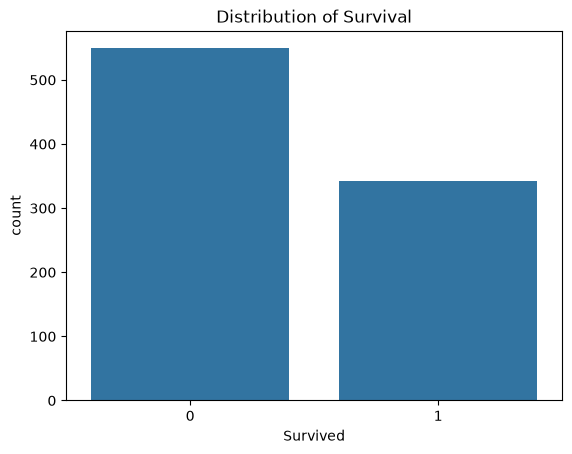

In [10]:
print(df["Survived"].value_counts())

print("\nPercentage Distribution:")
print((df["Survived"].value_counts(normalize=True) * 100).round(2))

sns.countplot(data=df, x="Survived")
plt.title("Distribution of Survival")
plt.show()

## Sex vs Survival

### Concept

We can compare a categorical feature with the target variable to understand whether different categories have different survival outcomes.

### Example

We compare the survival pattern of male and female passengers.

### Implementation

We use a grouped count plot and calculate the survival rate for each category.

### Interpretation

Differences in survival rates may indicate that Sex is an important feature for predicting survival.

### Insight

The relationship between Sex and Survived can provide useful information for Machine Learning models.

### AI/ML Relevance

Categorical variables that show a strong relationship with the target variable can be useful predictive features.

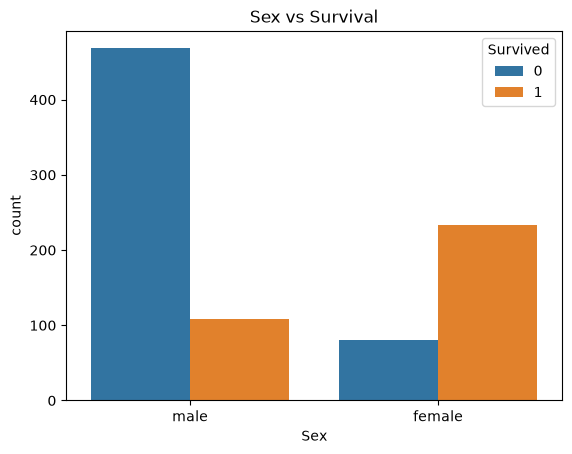

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [11]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Sex vs Survival")
plt.show()

print(df.groupby("Sex")["Survived"].mean())

## Embarked vs Survival

### Concept

We can also analyze whether the passenger's port of embarkation is related to survival.

### Example

Passengers from different embarkation ports may have different survival rates.

### Implementation

We group the data by Embarked and calculate the average survival rate.

### Interpretation

Differences in survival rates may suggest that Embarked has some relationship with the target variable.

### Insight

The relationship should be interpreted carefully because other variables may also influence survival.

### AI/ML Relevance

Analyzing feature-target relationships helps identify potentially useful variables for prediction.

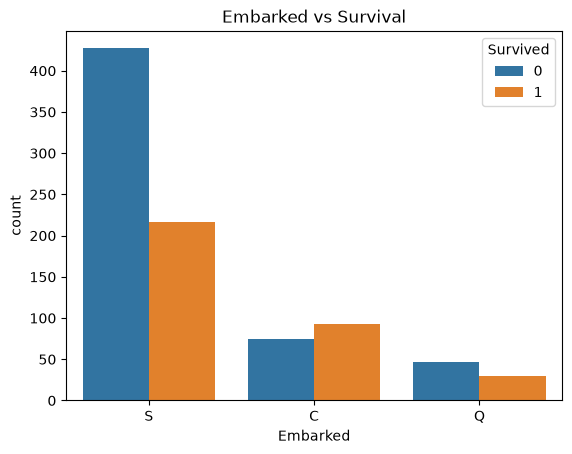

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [12]:
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Embarked vs Survival")
plt.show()

print(df.groupby("Embarked")["Survived"].mean())

# Conclusion

In this notebook, categorical variables in the Titanic dataset were analyzed using unique categories, category frequencies, percentage distributions, rare categories, cardinality, and category imbalance.

The analysis also examined relationships between important categorical variables and the Survived target variable.

Categorical analysis is useful for understanding the composition of the dataset, identifying imbalance or rare categories, and selecting suitable preprocessing and encoding methods for Machine Learning.